In [30]:
import zipfile
import pandas as pd

zip_path = "/home/bpipher/Projects/GraphExplore/data/MovieLens/ml-32m.zip"

# List the files in the zip to verify the structure
with zipfile.ZipFile(zip_path, 'r') as z:
    print(z.namelist())

# Create dataframes from the CSV files inside the zip
with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open('ml-32m/ratings.csv') as f:
        ratings = pd.read_csv(f)

    with z.open('ml-32m/movies.csv') as f:
        movies = pd.read_csv(f)

    with z.open('ml-32m/tags.csv') as f:
        tags = pd.read_csv(f)

    with z.open('ml-32m/links.csv') as f:
        links = pd.read_csv(f)

['ml-32m/', 'ml-32m/tags.csv', 'ml-32m/links.csv', 'ml-32m/README.txt', 'ml-32m/checksums.txt', 'ml-32m/ratings.csv', 'ml-32m/movies.csv']


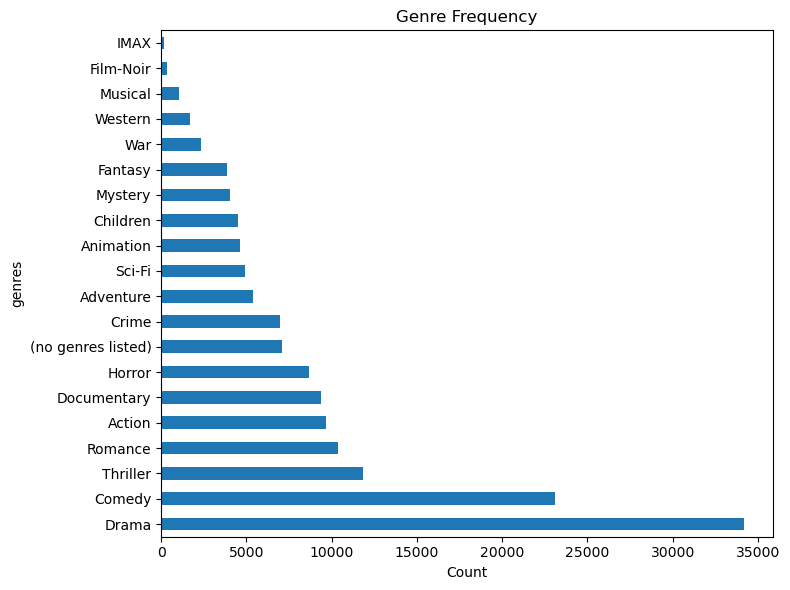

In [31]:
import matplotlib.pyplot as plt

genre_counts = movies['genres'].str.split('|').explode().value_counts()

genre_counts.plot(kind='barh', figsize=(8, 6))
plt.xlabel('Count')
plt.title('Genre Frequency')
plt.tight_layout()
plt.show()

In [ ]:
import torch
from torch_geometric.data import HeteroData

# --- Labels ---
movies['is_comedy'] = movies['genres'].str.contains('Comedy', na=False).astype(int)

# --- Re-index users and movies to 0-based ---
user_ids = ratings['userId'].unique()
movie_ids = movies['movieId'].unique()

print(f"Number of Users: {user_ids.shape}")
print(f"Number of Movies: {movie_ids.shape}")
print(f"Number of Duplicate Ratings: {ratings.duplicated(['userId', 'movieId']).sum()}")

Number of Users: (200948,)
Number of Movies: (87585,)
Number of Duplicate Ratings: 0


0                0
1                0
2                0
3                0
4                0
             ...  
32000199    200947
32000200    200947
32000201    200947
32000202    200947
32000203    200947
Length: 32000204, dtype: int32

In [53]:
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score, classification_report

svd = TruncatedSVD(n_components=16, random_state=42)
X = csr_matrix(
    (
        ratings["rating"].to_numpy(),
        (
            ratings["userId"].astype("category").cat.codes.to_numpy(),
            ratings["movieId"].astype("category").cat.codes.to_numpy(),
        ),
    )
)
svd.fit(X)
user_embeddings = svd.transform(X)
movie_embeddings = svd.components_.T

In [37]:
svd.fit(R)

,"n_components n_components: int, default=2Desired dimensionality of output data.If algorithm='arpack', must be strictly less than the number of features.If algorithm='randomized', must be less than or equal to the number of features.The default value is useful for visualisation. For LSA, a value of100 is recommended.",16
,"algorithm algorithm: {'arpack', 'randomized'}, default='randomized'SVD solver to use. Either ""arpack"" for the ARPACK wrapper in SciPy(scipy.sparse.linalg.svds), or ""randomized"" for the randomizedalgorithm due to Halko (2009).",'randomized'
,"n_iter n_iter: int, default=5Number of iterations for randomized SVD solver. Not used by ARPACK. Thedefault is larger than the default in:func:`~sklearn.utils.extmath.randomized_svd` to handle sparsematrices that may have large slowly decaying spectrum.",5
,"n_oversamples n_oversamples: int, default=10Number of oversamples for randomized SVD solver. Not used by ARPACK.See :func:`~sklearn.utils.extmath.randomized_svd` for a completedescription... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD solver.Not used by ARPACK. See :func:`~sklearn.utils.extmath.randomized_svd`for more details... versionadded:: 1.1",'auto'
,"random_state random_state: int, RandomState instance or None, default=NoneUsed during randomized svd. Pass an int for reproducible results acrossmultiple function calls.See :term:`Glossary `.",42
,"tol tol: float, default=0.0Tolerance for ARPACK. 0 means machine precision. Ignored by randomizedSVD solver.",0.0


In [38]:
movie_embeddings = svd.components_.T

In [40]:
movie_embeddings.shape

(292758, 16)

In [29]:
R,getrow(0)

NameError: name 'getrow' is not defined